In [113]:
%cd sample_data
!ls

[Errno 2] No such file or directory: 'sample_data'
/content/sample_data
anscombe.json		      mnist_test.csv	     synthetic_projects.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


#**Part 1. Importing the Dataset and Data Visualazation**

## **Part 1.1. Importing the Data**


In [114]:
import pandas as pd
df = pd.read_csv('synthetic_projects.csv')
print(df.head())

  Project_ID  Start_Date Location      Project_Type  Duration_Days Complexity  \
0      P0001  2023-09-22      ENA  Minor Renovation            403       High   
1      P0002  2023-11-12      KNA           Dry Lab            230     Medium   
2      P0003  2024-03-27      KNA           Dry Lab            294     Medium   
3      P0004  2023-05-03      ENG  Minor Renovation            367     Medium   
4      P0005  2024-08-03      ENC  Minor Renovation            373       High   

  Risk_Level  Area_sqm  Cost_Budgeted  Actual_Duration  Actual_Cost  
0     Medium        57          46600              515        58000  
1     Medium       495        3135000              263      4182200  
2     Medium        52         245700              379       321600  
3       High       214         312700              465       432900  
4       High        82         112100              449       146400  


## **Part 1.2. Checking the Data**

In [115]:
print('DataFrame Info:')
df.info()
print('\nDataFrame Description:')
print(df.describe(include='all'))
print('\nMissing Values:')
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Project_ID       1000 non-null   object
 1   Start_Date       1000 non-null   object
 2   Location         1000 non-null   object
 3   Project_Type     1000 non-null   object
 4   Duration_Days    1000 non-null   int64 
 5   Complexity       1000 non-null   object
 6   Risk_Level       1000 non-null   object
 7   Area_sqm         1000 non-null   int64 
 8   Cost_Budgeted    1000 non-null   int64 
 9   Actual_Duration  1000 non-null   int64 
 10  Actual_Cost      1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB

DataFrame Description:
       Project_ID  Start_Date Location      Project_Type  Duration_Days  \
count        1000        1000     1000              1000     1000.00000   
unique       1000         765       15                 7            

## **Part 1.3. Data Visualization**

### Part 1.3.1. Plotting for 'Duration_Days', 'Area_sqm', 'Cost_Budgeted', 'Actual_Duration', 'Actual_Cost'

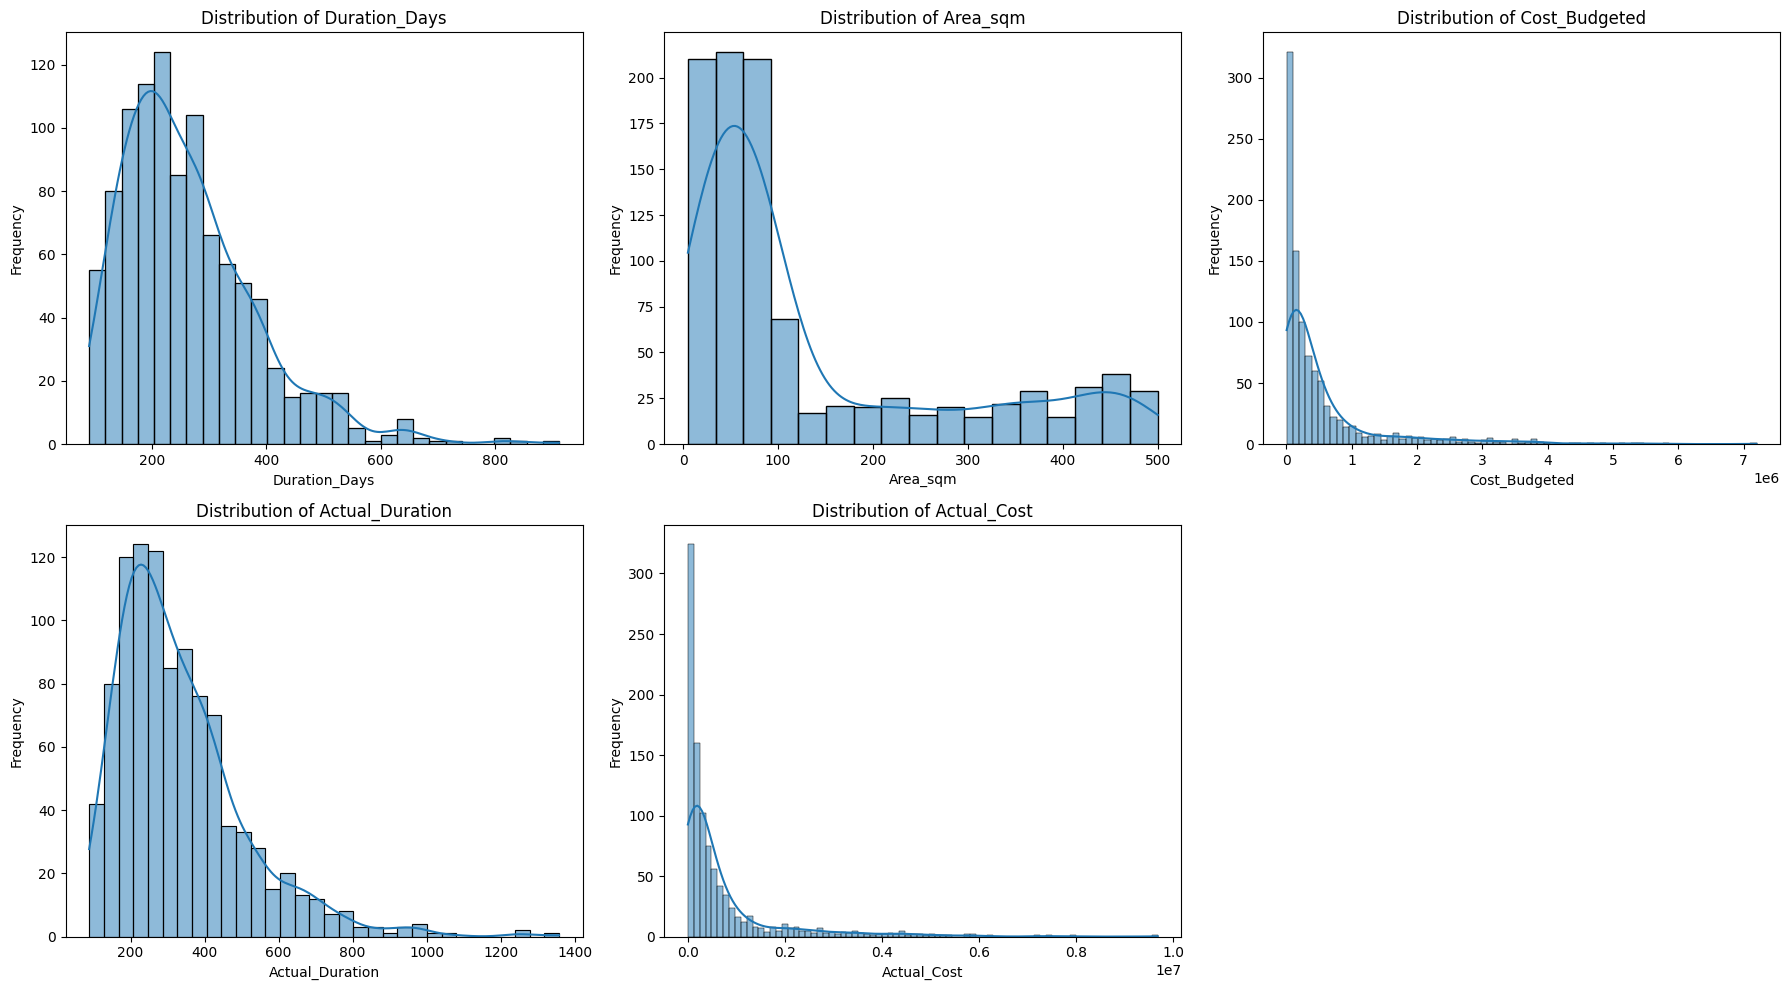

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Duration_Days', 'Area_sqm', 'Cost_Budgeted', 'Actual_Duration', 'Actual_Cost']

plt.figure(figsize=(18, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Part 1.3.2. Plotting The Projects Based on Location, Type, Complexity and Risk Level

/tmp/ipython-input-1806718108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipython-input-1806718108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipython-input-1806718108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipython-input-1806718108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is

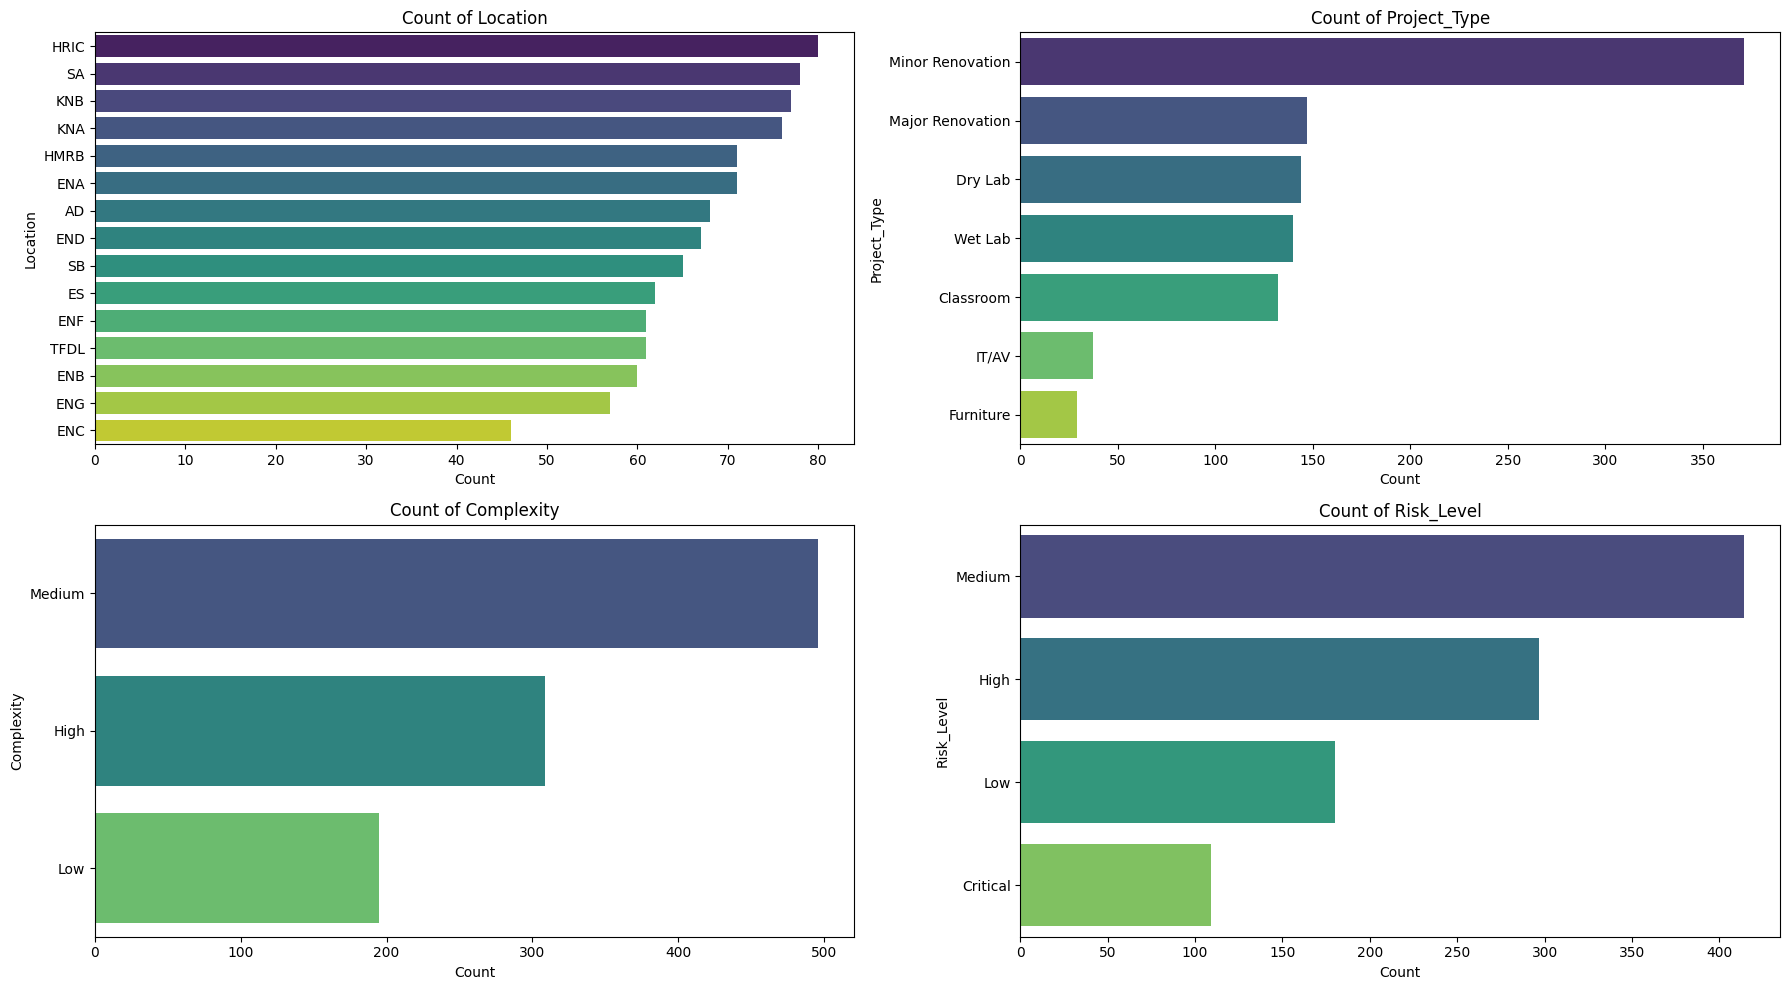

In [117]:
categorical_cols = ['Location', 'Project_Type', 'Complexity', 'Risk_Level']

plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Part 1.3.3. Plott the Actual Cost vs. Budgetted Cost & Actual Duration vs Planned Duration

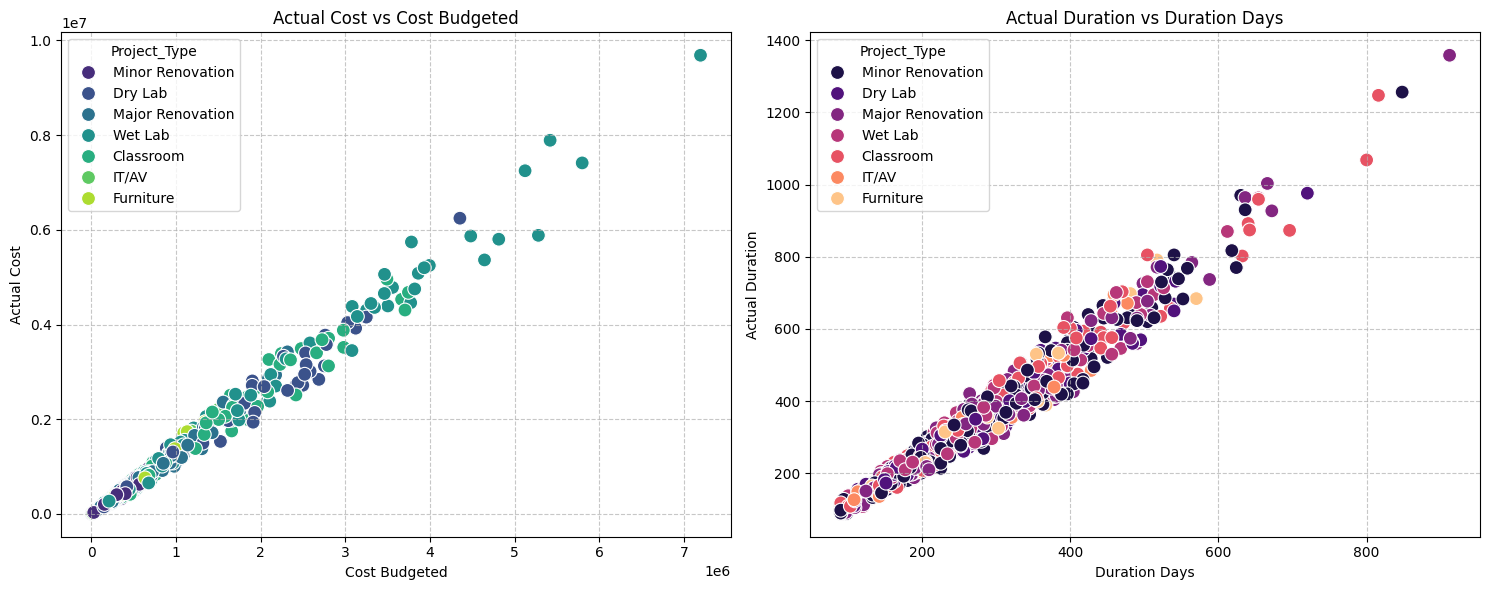

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Scatter plot for Actual_Cost vs Cost_Budgeted
plt.subplot(1, 2, 1)
sns.scatterplot(x='Cost_Budgeted', y='Actual_Cost', data=df, hue='Project_Type', palette='viridis', s=100)
plt.title('Actual Cost vs Cost Budgeted')
plt.xlabel('Cost Budgeted')
plt.ylabel('Actual Cost')
plt.grid(True, linestyle='--', alpha=0.7)

# Scatter plot for Actual_Duration vs Duration_Days
plt.subplot(1, 2, 2)
sns.scatterplot(x='Duration_Days', y='Actual_Duration', data=df, hue='Project_Type', palette='magma', s=100)
plt.title('Actual Duration vs Duration Days')
plt.xlabel('Duration Days')
plt.ylabel('Actual Duration')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **2. Predict the Actual Cost Using Linear Regression Model**

Dropping the 'Start_Date' column from the DataFrame and create a new DataFrame df_processed. Then, apply one-hot encoding to the specified categorical columns and display the head of the processed DataFrame.

In [119]:
df_processed = df.drop(columns=['Start_Date'])

categorical_features = ['Location', 'Project_Type', 'Complexity', 'Risk_Level']
df_processed = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True)

print(df_processed.head())

  Project_ID  Duration_Days  Area_sqm  Cost_Budgeted  Actual_Duration  \
0      P0001            403        57          46600              515   
1      P0002            230       495        3135000              263   
2      P0003            294        52         245700              379   
3      P0004            367       214         312700              465   
4      P0005            373        82         112100              449   

   Actual_Cost  Location_ENA  Location_ENB  Location_ENC  Location_END  ...  \
0        58000          True         False         False         False  ...   
1      4182200         False         False         False         False  ...   
2       321600         False         False         False         False  ...   
3       432900         False         False         False         False  ...   
4       146400         False         False          True         False  ...   

   Project_Type_Furniture  Project_Type_IT/AV  Project_Type_Major Renovation  \
0     

## **2.1. Data Splitting**

define the features (X) and the target variable (y), then split them into training and testing sets using train_test_split for reproducibility and verify the shapes of the resulting sets (test_size=0.2, random_state=42).


In [120]:
import numpy as np
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=['Project_ID','Actual_Cost','Actual_Duration','Cost_Budgeted', 'Duration_Days'])
y = df_processed['Actual_Cost']

# Log-transform the target
y_log = np.log1p(y)   # log(1 + y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train_log.shape}')
print(f'Shape of y_test: {y_test_log.shape}')

Shape of X_train: (800, 26)
Shape of X_test: (200, 26)
Shape of y_train: (800,)
Shape of y_test: (200,)


In [121]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **2.2. Model Selection and Training**

In [122]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train_log)

print("Linear Regression model with positive coefficients trained successfully.")

Linear Regression model with positive coefficients trained successfully.


## **2.3. Model Evaluation**

In [123]:
# Predict on log scale
y_pred_log = model.predict(X_test_scaled)
print("Predictions on the test set generated successfully.")

Predictions on the test set generated successfully.


In [124]:
# Invert back to original scale
y_pred = np.expm1(y_pred_log)   # exp(y) - 1
y_test = np.expm1(y_test_log)

In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 267465.55
Mean Squared Error (MSE): 395647402993.40
Root Mean Squared Error (RMSE): 629005.09
R-squared (R2): 0.73


### *2.3.1. Visualizing Predicted Cost vs. Actual Cost by Project Type*

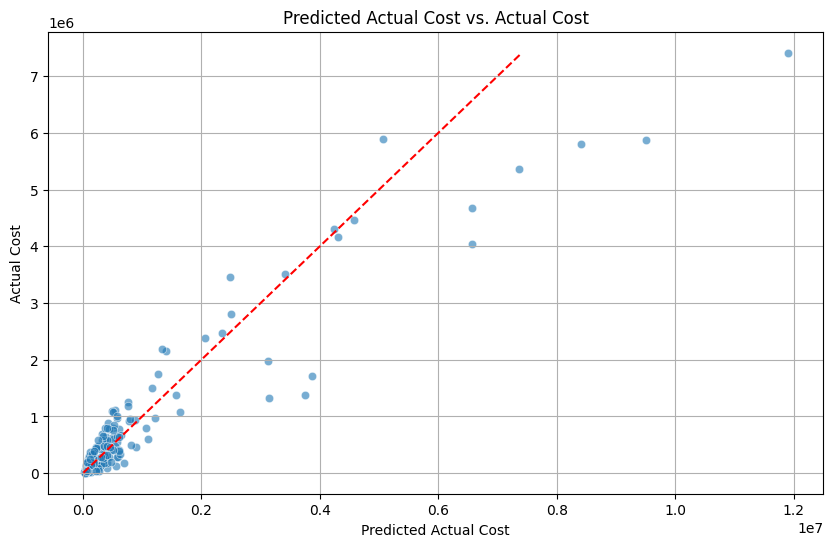

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=y_test, alpha=0.6)
plt.xlabel('Predicted Actual Cost')
plt.ylabel('Actual Cost')
plt.title('Predicted Actual Cost vs. Actual Cost')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()

### *2.3.2. Feature Importance Coefficients*

Top 10 Feature Importance Coefficients:


,Feature,Coefficient,Abs_Coefficient
0,Area_sqm,0.961535,0.961535
19,Project_Type_Minor Renovation,-0.900316,0.900316
18,Project_Type_Major Renovation,-0.260556,0.260556
25,Risk_Level_Medium,-0.214469,0.214469
17,Project_Type_IT/AV,-0.212864,0.212864
24,Risk_Level_Low,-0.182297,0.182297
21,Complexity_Low,-0.155727,0.155727
20,Project_Type_Wet Lab,0.155275,0.155275
16,Project_Type_Furniture,-0.145967,0.145967
23,Risk_Level_High,-0.097138,0.097138


/tmp/ipython-input-3798450897.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(20), palette='viridis', legend=False)


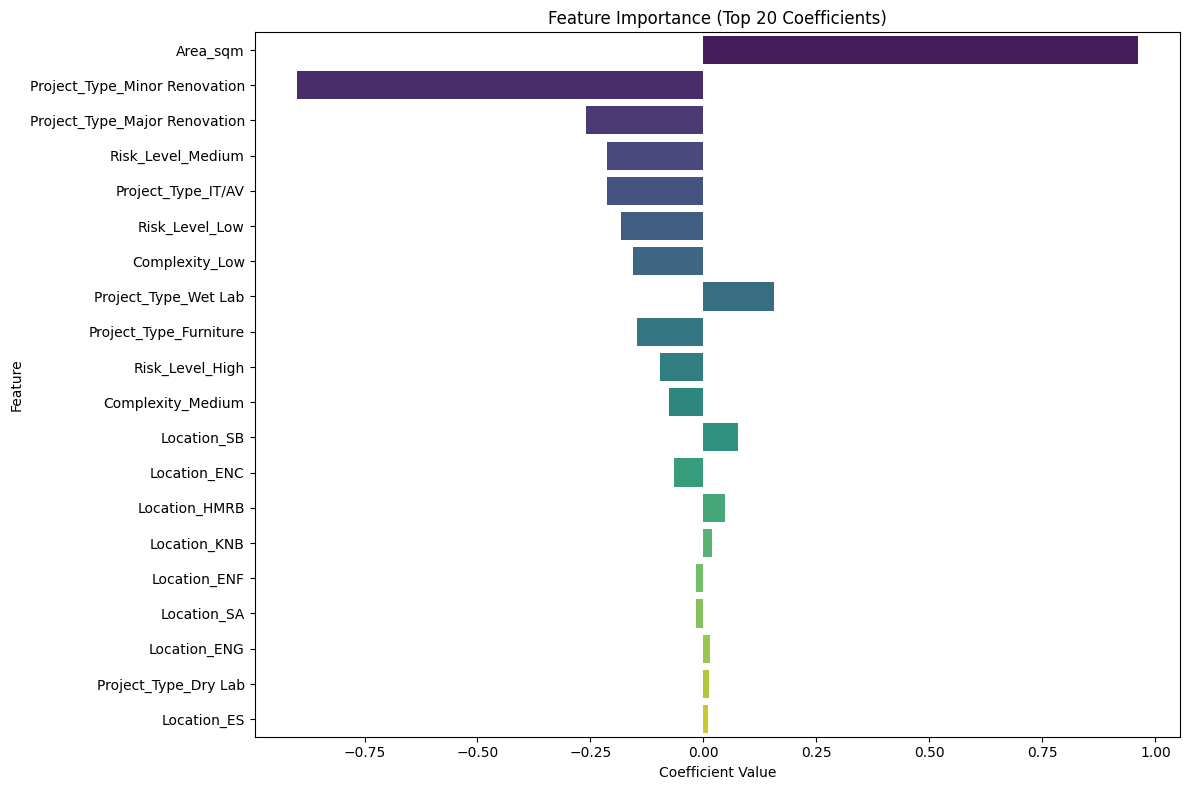

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from X_train (before scaling, as scaling does not change feature order)
feature_names = X_train.columns

# Get coefficients from the trained model
coefficients = model.coef_

# Create a DataFrame to store feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by the absolute value of coefficients to see the most impactful features
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Feature Importance Coefficients:")
display(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(20), palette='viridis', legend=False)
plt.title('Feature Importance (Top 20 Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# **3. Predict the Actual Cost Using Random Forest Regressor**

## **3.1. Data Splitting**

In [128]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=['Project_ID','Actual_Cost','Actual_Duration', 'Cost_Budgeted', 'Duration_Days'])
y = df_processed['Actual_Cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (800, 26)
Shape of X_test: (200, 26)
Shape of y_train: (800,)
Shape of y_test: (200,)


## **3.2. Model Selection and Training**

In [129]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


## **3.3. Model Evaluation**

In [130]:
y_pred = rf_model.predict(X_test)
print("Predictions on the test set generated successfully.")

Predictions on the test set generated successfully.


In [131]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 182277.13
Mean Squared Error (MSE): 111174575423.31
Root Mean Squared Error (RMSE): 333428.52
R-squared (R2): 0.92


### *3.3.1. Visualizing Predicted Cost vs. Actual Cost by Project Type*

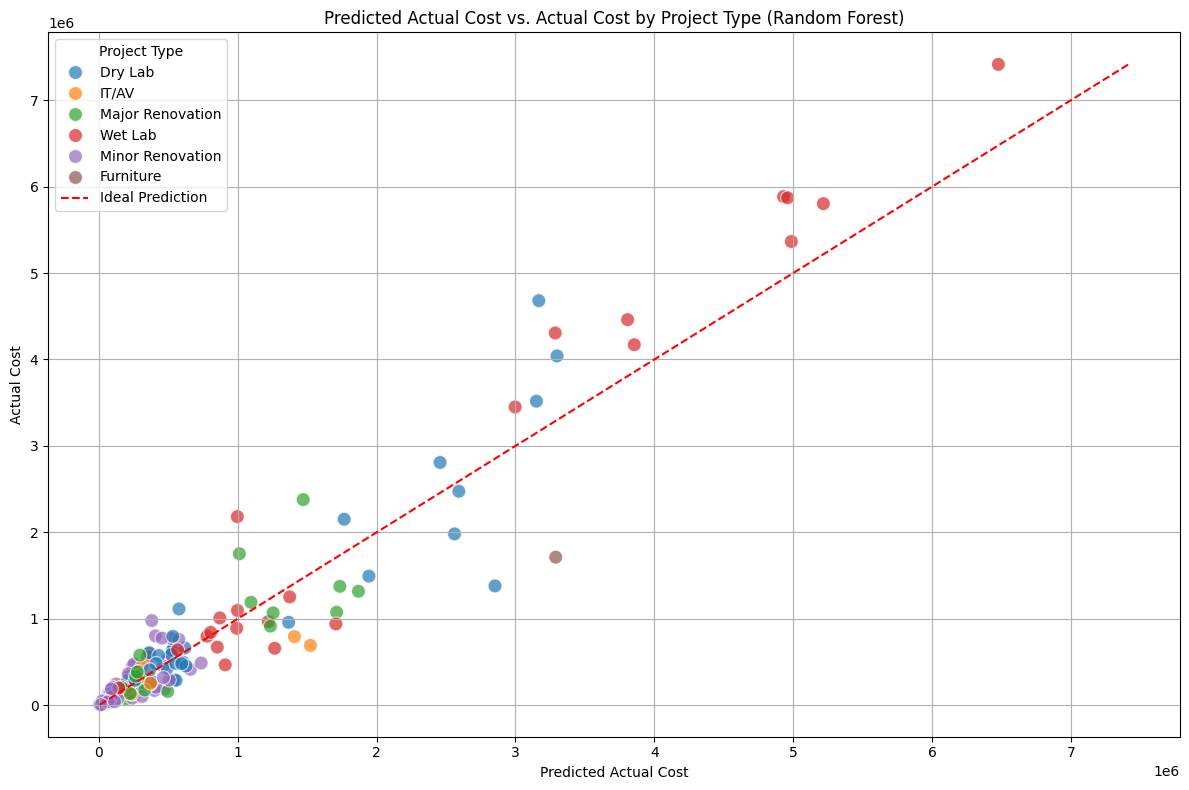

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Actual_Cost': y_test,
    'Predicted_Cost': y_pred
})

# Get the Project_Type columns from X_test for the corresponding test samples
project_type_cols = [col for col in X_test.columns if 'Project_Type_' in col]
project_types_df = X_test[project_type_cols]

# Reconstruct the original Project_Type from one-hot encoded columns
# Find the column that is True for each row, and use its name (removing the prefix)
# Note: idxmax will return the first True column, assuming only one Project_Type is true per row.
plot_df['Project_Type'] = project_types_df.idxmax(axis=1).str.replace('Project_Type_', '')

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Predicted_Cost', y='Actual_Cost', hue='Project_Type', data=plot_df, palette='tab10', s=100, alpha=0.7)
plt.xlabel('Predicted Actual Cost')
plt.ylabel('Actual Cost')
plt.title('Predicted Actual Cost vs. Actual Cost by Project Type (Random Forest)')
plt.plot([plot_df['Actual_Cost'].min(), plot_df['Actual_Cost'].max()],
         [plot_df['Actual_Cost'].min(), plot_df['Actual_Cost'].max()],
         'r--', label='Ideal Prediction')
plt.grid(True)
plt.legend(title='Project Type')
plt.tight_layout()
plt.show()

### *3.3.2. Feature Importance Coefficients*

Top 10 Feature Importances for Random Forest Regressor:


,Feature,Importance
0,Area_sqm,0.556371
19,Project_Type_Minor Renovation,0.203910
20,Project_Type_Wet Lab,0.105977
18,Project_Type_Major Renovation,0.032224
17,Project_Type_IT/AV,0.010923
24,Risk_Level_Low,0.009319
7,Location_ES,0.008957
11,Location_KNB,0.007652
21,Complexity_Low,0.007397
23,Risk_Level_High,0.006556


/tmp/ipython-input-2788663077.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis', legend=False)


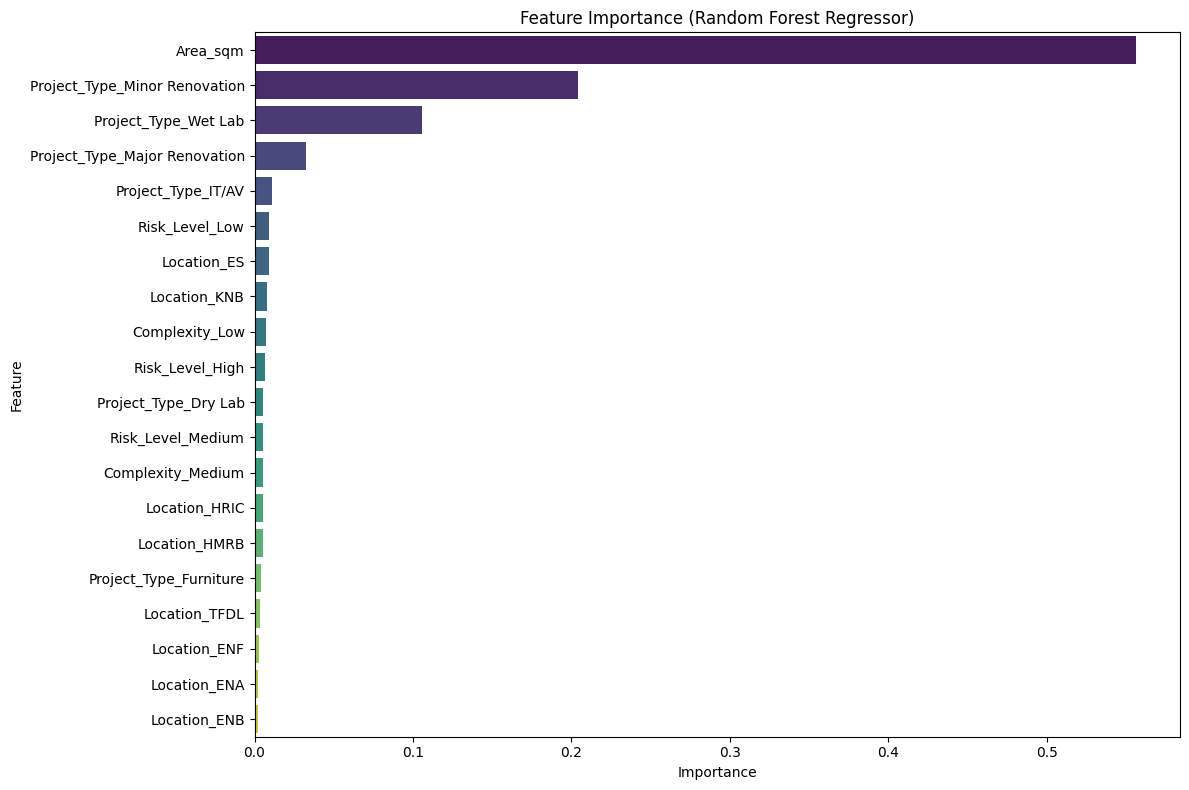

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances for Random Forest Regressor:")
display(importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis', legend=False)
plt.title('Feature Importance (Random Forest Regressor)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#**4. Predict the Actual Cost Using Random Forest Regressor**

## **4.1. Data Splitting**

In [134]:
df_processed_xgb_no_cost_duration = df.drop(columns=['Start_Date', 'Cost_Budgeted', 'Duration_Days', 'Actual_Duration'])

categorical_features = ['Location', 'Project_Type', 'Complexity', 'Risk_Level']
df_processed_xgb_no_cost_duration = pd.get_dummies(df_processed_xgb_no_cost_duration, columns=categorical_features, drop_first=True)

print(df_processed_xgb_no_cost_duration.head())

  Project_ID  Area_sqm  Actual_Cost  Location_ENA  Location_ENB  Location_ENC  \
0      P0001        57        58000          True         False         False   
1      P0002       495      4182200         False         False         False   
2      P0003        52       321600         False         False         False   
3      P0004       214       432900         False         False         False   
4      P0005        82       146400         False         False          True   

   Location_END  Location_ENF  Location_ENG  Location_ES  ...  \
0         False         False         False        False  ...   
1         False         False         False        False  ...   
2         False         False         False        False  ...   
3         False         False          True        False  ...   
4         False         False         False        False  ...   

   Project_Type_Furniture  Project_Type_IT/AV  Project_Type_Major Renovation  \
0                   False               Fa

In [135]:
from sklearn.model_selection import train_test_split

X_xgb_no_cost_duration = df_processed_xgb_no_cost_duration.drop(columns=['Project_ID', 'Actual_Cost'])
y_xgb_no_cost_duration = df_processed_xgb_no_cost_duration['Actual_Cost']

X_train_xgb_no_cost_duration, X_test_xgb_no_cost_duration, y_train_xgb_no_cost_duration, y_test_xgb_no_cost_duration = train_test_split(
    X_xgb_no_cost_duration, y_xgb_no_cost_duration, test_size=0.2, random_state=42
)

print(f'Shape of X_train_xgb_no_cost_duration: {X_train_xgb_no_cost_duration.shape}')
print(f'Shape of X_test_xgb_no_cost_duration: {X_test_xgb_no_cost_duration.shape}')
print(f'Shape of y_train_xgb_no_cost_duration: {y_train_xgb_no_cost_duration.shape}')
print(f'Shape of y_test_xgb_no_cost_duration: {y_test_xgb_no_cost_duration.shape}')

Shape of X_train_xgb_no_cost_duration: (800, 26)
Shape of X_test_xgb_no_cost_duration: (200, 26)
Shape of y_train_xgb_no_cost_duration: (800,)
Shape of y_test_xgb_no_cost_duration: (200,)


## **4.2. Model Selection and Training**

In [136]:
from xgboost import XGBRegressor

xgb_model_no_cost_duration = XGBRegressor(random_state=42)
xgb_model_no_cost_duration.fit(X_train_xgb_no_cost_duration, y_train_xgb_no_cost_duration)

print("XGBoost Regressor model trained successfully without Cost_Budgeted and duration-related features.")

XGBoost Regressor model trained successfully without Cost_Budgeted and duration-related features.


In [137]:
y_pred_xgb_no_cost_duration = xgb_model_no_cost_duration.predict(X_test_xgb_no_cost_duration)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb_no_cost_duration = mean_absolute_error(y_test_xgb_no_cost_duration, y_pred_xgb_no_cost_duration)
mse_xgb_no_cost_duration = mean_squared_error(y_test_xgb_no_cost_duration, y_pred_xgb_no_cost_duration)
rmse_xgb_no_cost_duration = np.sqrt(mse_xgb_no_cost_duration)
r2_xgb_no_cost_duration = r2_score(y_test_xgb_no_cost_duration, y_pred_xgb_no_cost_duration)

print(f"XGBoost Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae_xgb_no_cost_duration:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb_no_cost_duration:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_no_cost_duration:.2f}")
print(f"R-squared (R2): {r2_xgb_no_cost_duration:.2f}")

XGBoost Regressor Performance:
Mean Absolute Error (MAE): 153651.55
Mean Squared Error (MSE): 79595388928.00
Root Mean Squared Error (RMSE): 282126.55
R-squared (R2): 0.95


## **4.3. Model Evaluation**

### *4.3.1. Visualizing Predicted Cost vs. Actual Cost by Project Type*

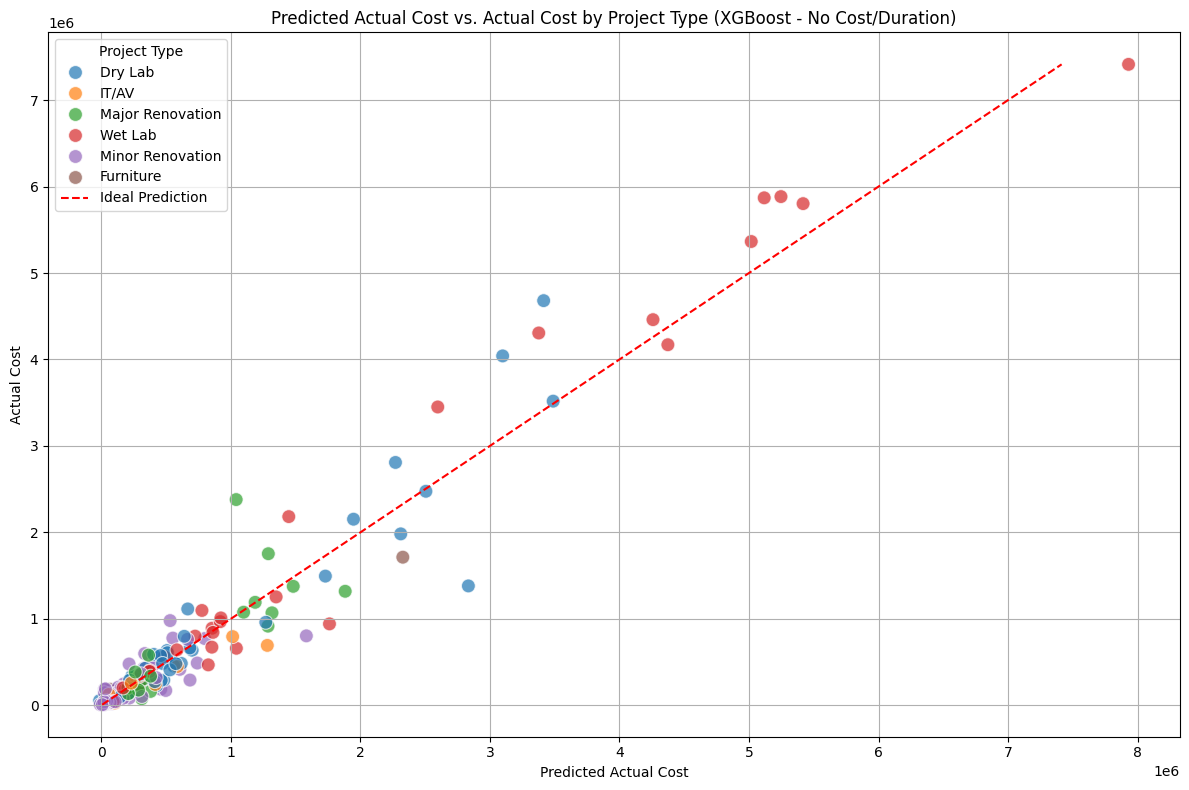

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting
plot_df_xgb = pd.DataFrame({
    'Actual_Cost': y_test_xgb_no_cost_duration,
    'Predicted_Cost': y_pred_xgb_no_cost_duration
})

# Get the Project_Type columns from X_test_xgb_no_cost_duration
project_type_cols_xgb = [col for col in X_test_xgb_no_cost_duration.columns if 'Project_Type_' in col]
project_types_df_xgb = X_test_xgb_no_cost_duration[project_type_cols_xgb]

# Reconstruct the original Project_Type from one-hot encoded columns
plot_df_xgb['Project_Type'] = project_types_df_xgb.idxmax(axis=1).str.replace('Project_Type_', '')

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Predicted_Cost', y='Actual_Cost', hue='Project_Type', data=plot_df_xgb, palette='tab10', s=100, alpha=0.7)
plt.xlabel('Predicted Actual Cost')
plt.ylabel('Actual Cost')
plt.title('Predicted Actual Cost vs. Actual Cost by Project Type (XGBoost - No Cost/Duration)')
plt.plot([plot_df_xgb['Actual_Cost'].min(), plot_df_xgb['Actual_Cost'].max()],
         [plot_df_xgb['Actual_Cost'].min(), plot_df_xgb['Actual_Cost'].max()],
         'r--', label='Ideal Prediction')
plt.grid(True)
plt.legend(title='Project Type')
plt.tight_layout()
plt.show()

### *4.3.2. Feature Importance Coefficients*

/tmp/ipython-input-1419820527.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb_no_cost_duration_df.head(15), palette='magma', legend=False)


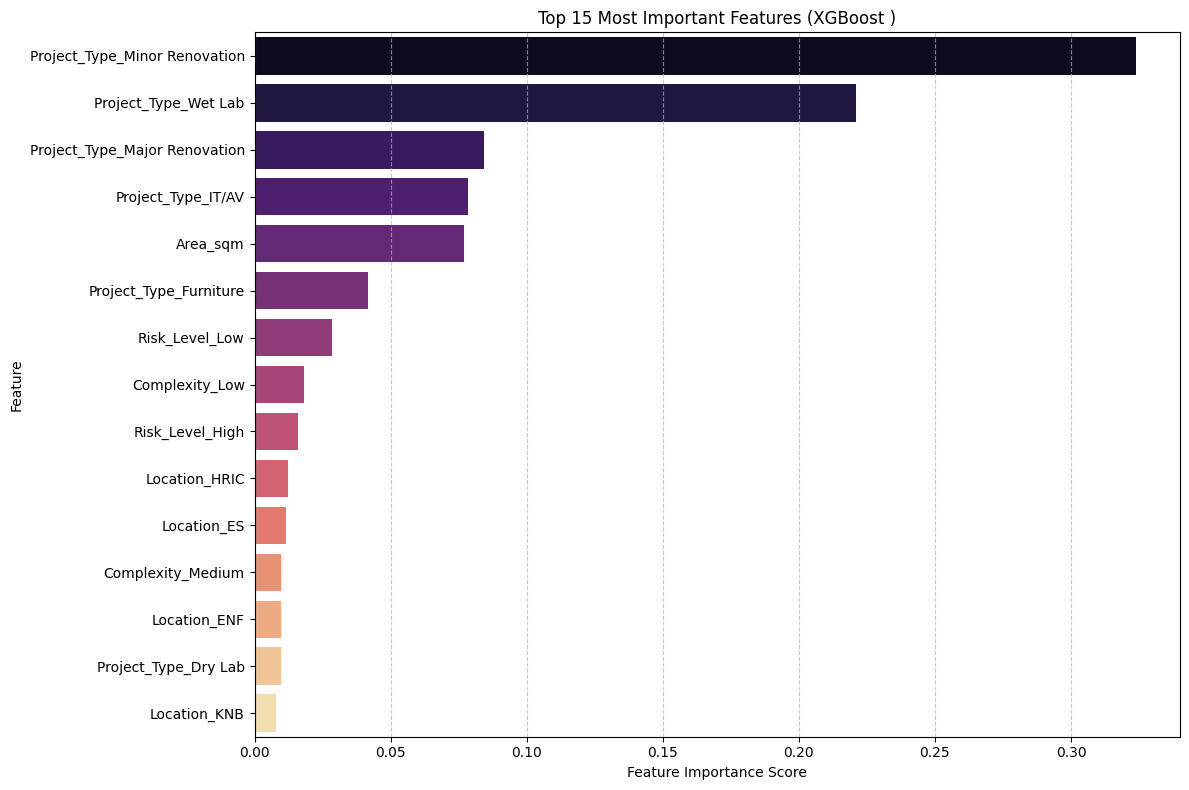

In [139]:
import pandas as pd

# Get feature importances from the trained XGBoost model
xgb_feature_importances_no_cost_duration = xgb_model_no_cost_duration.feature_importances_

# Get feature names from X_train_xgb_no_cost_duration
feature_names_xgb_no_cost_duration = X_train_xgb_no_cost_duration.columns

# Create a DataFrame to display feature importance
feature_importance_xgb_no_cost_duration_df = pd.DataFrame({
    'Feature': feature_names_xgb_no_cost_duration,
    'Importance': xgb_feature_importances_no_cost_duration
})

# Sort by importance in descending order
feature_importance_xgb_no_cost_duration_df = feature_importance_xgb_no_cost_duration_df.sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb_no_cost_duration_df.head(15), palette='magma', legend=False)
plt.title('Top 15 Most Important Features (XGBoost )')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **5. Comparing the Models**

In [140]:
import pandas as pd
import numpy as np

# Linear Regression Metrics (from cell 3z1KcGB8MZqz)
# Note: These variable names are overwritten in the next block for RF, so re-fetch if needed or ensure unique names
# For the purpose of this comparison, I'll use the final values stored in the kernel from their respective execution.

# Retrieve metrics for Linear Regression (from previous cell output for 3z1KcGB8MZqz)
# Using hardcoded values as they are available in the kernel state
lr_mae = 267465.55
lr_mse = 395647402993.40
lr_rmse = 629005.09
lr_r2 = 0.73

# Retrieve metrics for Random Forest (from previous cell output for tDozRRx-Qbbu)
rf_mae = 182277.13
rf_mse = 111174575423.31
rf_rmse = 333428.52
rf_r2 = 0.92

# Retrieve metrics for XGBoost (from previous cell output for Z66ZuUw5XZTN)
xgb_mae = 153651.55
xgb_mse = 79595388928.00
xgb_rmse = 282126.55
xgb_r2 = 0.95

# Create a DataFrame for comparison
metrics_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'MSE': [lr_mse, rf_mse, xgb_mse],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'R2': [lr_r2, rf_r2, xgb_r2]
}

comparison_df = pd.DataFrame(metrics_data)

print("\nModel Performance Comparison:")
display(comparison_df)

print("\n--- Analysis ---")
print("Based on the performance metrics:")
print("1.  **Mean Absolute Error (MAE):** This metric represents the average absolute difference between predicted and actual values. Lower MAE is better. XGBoost has the lowest MAE (153651.55), followed by Random Forest (182277.13) and then Linear Regression (267465.55).")
print("2.  **Mean Squared Error (MSE) / Root Mean Squared Error (RMSE):** These metrics penalize larger errors more heavily. Lower values are better. Again, XGBoost has the lowest MSE (79595388928.00) and RMSE (282126.55), indicating better overall accuracy and smaller prediction errors.")
print("3.  **R-squared (R2):** This metric indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R2 value (closer to 1) is better. XGBoost has the highest R2 score (0.95), meaning it explains 95% of the variance in actual costs, which is excellent. Random Forest is close with 0.92, while Linear Regression is significantly lower at 0.73.")

print("\n**Conclusion:**\nBased on all evaluated metrics (MAE, MSE, RMSE, and R2), the **XGBoost model** clearly outperforms both the Random Forest and Linear Regression models. It demonstrates the highest predictive accuracy and explains the most variance in the actual cost, making it the best-performing model for this task among the three evaluated.")


Model Performance Comparison:


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,267465.55,3.956474e+11,629005.09,0.73
1,Random Forest,182277.13,1.111746e+11,333428.52,0.92
2,XGBoost,153651.55,7.959539e+10,282126.55,0.95



--- Analysis ---
Based on the performance metrics:
1.  **Mean Absolute Error (MAE):** This metric represents the average absolute difference between predicted and actual values. Lower MAE is better. XGBoost has the lowest MAE (153651.55), followed by Random Forest (182277.13) and then Linear Regression (267465.55).
2.  **Mean Squared Error (MSE) / Root Mean Squared Error (RMSE):** These metrics penalize larger errors more heavily. Lower values are better. Again, XGBoost has the lowest MSE (79595388928.00) and RMSE (282126.55), indicating better overall accuracy and smaller prediction errors.
3.  **R-squared (R2):** This metric indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R2 value (closer to 1) is better. XGBoost has the highest R2 score (0.95), meaning it explains 95% of the variance in actual costs, which is excellent. Random Forest is close with 0.92, while Linear Regression is significantly lower at 

## **Analysis Based on the performance metrics:**
1.  **Mean Absolute Error (MAE):** This metric represents the average absolute difference between predicted and actual values. Lower MAE is better. XGBoost has the lowest MAE (153651.55), followed by Random Forest (182277.13) and then Linear Regression (267465.55).
2.  **Mean Squared Error (MSE) / Root Mean Squared Error (RMSE):** These metrics penalize larger errors more heavily. Lower values are better. Again, XGBoost has the lowest MSE (79595388928.00) and RMSE (282126.55), indicating better overall accuracy and smaller prediction errors.
3.  **R-squared (R2):** This metric indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R2 value (closer to 1) is better. XGBoost has the highest R2 score (0.95), meaning it explains 95% of the variance in actual costs, which is excellent. Random Forest is close with 0.92, while Linear Regression is significantly lower at 0.73.

**Conclusion:**
Based on all evaluated metrics (MAE, MSE, RMSE, and R2), the **XGBoost model** clearly outperforms both the Random Forest and Linear Regression models. It demonstrates the highest predictive accuracy and explains the most variance in the actual cost, making it the best-performing model for this task among the three evaluated.\